<a href="https://colab.research.google.com/github/nooshinsina/remdesivir-faers-q3-2020/blob/main/remdesivir-faers-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://fis.fda.gov/content/Exports/faers_ascii_2020q1.zip

--2026-09-22 15:10:29--  https://fis.fda.gov/content/Exports/faers_ascii_2020q1.zip
Resolving fis.fda.gov (fis.fda.gov)... 150.148.26.113
Connecting to fis.fda.gov (fis.fda.gov)|150.148.26.113|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘faers_ascii_2020q1.zip.4’

faers_ascii_2020q1.     [    <=>             ]  65.16M  1.02MB/s    in 64s     

2026-09-22 15:11:34 (1.01 MB/s) - ‘faers_ascii_2020q1.zip.4’ saved [68320375]



In [ ]:
!unzip -o faers_ascii_2020q1.zip.4

Archive:  faers_ascii_2020q1.zip.4
  inflating: ASCII/ASC_NTS.pdf       
  inflating: ASCII/demo20q1.pdf      
  inflating: ASCII/DEMO20Q1.txt      
  inflating: ASCII/drug20q1.pdf      
  inflating: ASCII/DRUG20Q1.txt      
  inflating: ASCII/indi20q1.pdf      
  inflating: ASCII/INDI20Q1.txt      
  inflating: ASCII/outc20q1.pdf      
  inflating: ASCII/OUTC20Q1.txt      
  inflating: ASCII/reac20q1.pdf      
  inflating: ASCII/REAC20Q1.txt      
  inflating: ASCII/rpsr20q1.pdf      
  inflating: ASCII/RPSR20Q1.txt      
  inflating: ASCII/THER20Q1.PDF      
  inflating: ASCII/THER20Q1.txt      
  inflating: DELETED/ADR20Q1DeletedCases.txt  
  inflating: FAQs.pdf                
  inflating: Readme.pdf              


In [ ]:

import pandas as pd

demo = pd.read_csv("ASCII/DEMO20Q1.txt", sep="$", encoding='latin-1', low_memory=False)
drug = pd.read_csv("ASCII/DRUG20Q1.txt", sep="$", encoding='latin-1', low_memory=False)
reac = pd.read_csv("ASCII/REAC20Q1.txt", sep="$", encoding='latin-1', low_memory=False)

print("شد!")
print(demo.shape, drug.shape, reac.shape)
print(demo.head(2))

شد!
(460327, 25) (1943532, 20) (1517264, 4)
   primaryid    caseid  caseversion i_f_code  event_dt      mfr_dt  \
0  100046942  10004694            2        F       NaN  20200108.0   
1  100048206  10004820            6        F       NaN  20200305.0   

   init_fda_dt    fda_dt rept_cod auth_num  ... age_grp sex e_sub    wt  \
0     20140312  20200110      EXP      NaN  ...     NaN   F     Y  81.0   
1     20140312  20200309      EXP      NaN  ...     NaN   F     Y   NaN   

  wt_cod     rept_dt to_mfr occp_cod  reporter_country occr_country  
0     KG  20200110.0    NaN       LW                US           US  
1    NaN  20200309.0    NaN       MD                US           US  

[2 rows x 25 columns]


In [ ]:

# فقط داروهایی که متهم اصلی بودن (PS)
drug_ps = drug[drug['role_cod'] == 'PS']

# فقط رمدسیویر
rem = drug_ps[drug_ps['drugname'].str.contains('remdesivir', case=False, na=False)]

print(f"تعداد گزارش رمدسیویر به عنوان متهم اصلی: {len(rem)}")
print(rem[['primaryid','drugname']].head())

تعداد گزارش رمدسیویر به عنوان متهم اصلی: 0
Empty DataFrame
Columns: [primaryid, drugname]
Index: []


In [ ]:
# Q3 2020 که رمدسیویر توش هست
!wget https://fis.fda.gov/content/Exports/faers_ascii_2020q3.zip
!unzip -o faers_ascii_2020q3.zip

drug = pd.read_csv("ASCII/DRUG20Q3.txt", sep="$", encoding='latin-1', low_memory=False)
drug_ps = drug[drug['role_cod'] == 'PS']
rem = drug_ps[drug_ps['drugname'].str.contains('remdesivir|VEKLURY', case=False, na=False)]

print(f"تعداد گزارش رمدسیویر در Q3 2020: {len(rem)}")
print(rem['drugname'].value_counts().head())

--2026-09-22 15:33:27--  https://fis.fda.gov/content/Exports/faers_ascii_2020q3.zip
Resolving fis.fda.gov (fis.fda.gov)... 150.148.26.113
Connecting to fis.fda.gov (fis.fda.gov)|150.148.26.113|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘faers_ascii_2020q3.zip’

faers_ascii_2020q3.     [   <=>              ]  63.36M  1024KB/s    in 63s     

2026-09-22 15:34:30 (1.00 MB/s) - ‘faers_ascii_2020q3.zip’ saved [66442726]

Archive:  faers_ascii_2020q3.zip
  inflating: ASCII/ASC_NTS.pdf       
  inflating: ASCII/demo20q3.pdf      
  inflating: ASCII/DEMO20Q3.txt      
  inflating: ASCII/drug20q3.pdf      
  inflating: ASCII/DRUG20Q3.txt      
  inflating: ASCII/indi20q3.pdf      
  inflating: ASCII/INDI20Q3.txt      
  inflating: ASCII/outc20q3.pdf      
  inflating: ASCII/OUTC20Q3.txt      
  inflating: ASCII/reac20q3.pdf      
  inflating: ASCII/REAC20Q3.txt      
  inflating: ASCII/rpsr20q3.pdf      
  inflating: ASCII/

In [ ]:
# فایل عارضه همین فصل
reac = pd.read_csv("ASCII/REAC20Q3.txt", sep="$", encoding='latin-1', low_memory=False)

# فقط عارضه های همون ۱۹۱۱ نفر
rem_ids = rem['primaryid'].unique()
rem_reac = reac[reac['primaryid'].isin(rem_ids)]

print(rem_reac['pt'].value_counts().head(10))

pt
Alanine aminotransferase increased      469
Aspartate aminotransferase increased    292
Liver function test increased           206
Acute kidney injury                     168
Death                                   152
Blood creatinine increased              137
Bradycardia                              99
Cardiac arrest                           92
Therapy cessation                        78
Transaminases increased                  73
Name: count, dtype: int64


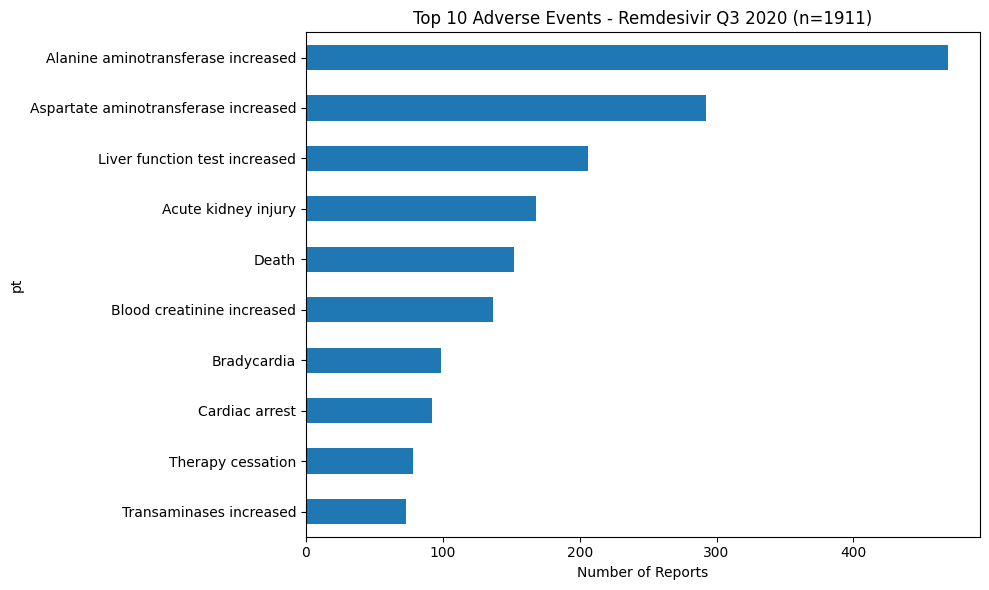

In [ ]:
import matplotlib.pyplot as plt

# rem_reac همون که ساختی
top10 = rem_reac['pt'].value_counts().head(10)

plt.figure(figsize=(10,6))
top10.sort_values().plot(kind='barh')
plt.xlabel('Number of Reports')
plt.title('Top 10 Adverse Events - Remdesivir Q3 2020 (n=1911)')
plt.tight_layout()
plt.savefig('remdesivir_chart.png')
plt.show()

In [ ]:
# کل ری اکشن ها
total_reac = len(reac)
rem_total = len(rem_reac)

# برای ALT
a = 469  # از خروجی خودت
b = rem_total - a
c = reac['pt'].value_counts()['Alanine aminotransferase increased'] - a
d = total_reac - a - b - c

prr = (a/(a+b)) / (c/(c+d))

print(f"a={a}, b={b}, c={c}, d={d}")
print(f"PRR = {prr:.2f}")

a=469, b=4127, c=1272, d=1448176
PRR = 116.28


In [ ]:
# تعداد کل عارضه ها
rem_total = len(rem_reac)
total = len(reac)

a = 469 # ALT با رمدسیویر - از خروجی خودت
b = rem_total - a
c = reac['pt'].value_counts().get('Alanine aminotransferase increased', 0) - a
d = total - a - b - c

prr = (a/(a+b)) / (c/(c+d)) if c>0 else 0

print(f"PRR for ALT increased = {prr:.1f}")

PRR for ALT increased = 116.3


In [ ]:
# برای کلیه
a2 = 168
b2 = rem_total - a2
c2 = reac['pt'].value_counts().get('Acute kidney injury', 0) - a2
d2 = total - a2 - b2 - c2
prr2 = (a2/(a2+b2)) / (c2/(c2+d2))
print(f"PRR kidney = {prr2:.1f}")

PRR kidney = 10.8
